In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

import ladder
plt.close()

In [ ]:
pull_predictions_from_weka("aws")

In [4]:
def task_tag(task_name):
    return task_name.split("::")[0].replace(":rc", "") if "::" in task_name else task_name

selected_tasks = [
    'arc_challenge', 'arc_challenge:mc'
]

TASKS = [task_tag(task) for task in selected_tasks]

In [5]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice'] # accuracy benchmarks

df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet', columns=COLS)

# only keep entries from the relevant tasks
# df = df.loc[pd.IndexSlice[TASKS, :, :, :], :]

print(f'Loaded {len(df):,} instance predictions')

Loaded 73,080,000 instance predictions


In [6]:
MODELS = df.index.get_level_values('model').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()

In [7]:
# not loading these metrics
df["exact_match"] = 0
df["pass_at_1"] = 0
df["pass_at_10"] = 0

### Predicting RC with MC

In [8]:
from ladder import sort_experiment_names
from utils.constants_models import MODEL_LIST_MIXES

# Train models
all_ladder_models = [model for model in MODELS if 'peteish-moreeval' in model]
all_ladder_models = sort_experiment_names(all_ladder_models)

# Ladder config
ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/final_moredata.json'

# Eval models
MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = ["gemma-2b", "gemma-7b", "gemma-2-2b", "gemma-2-9b"] # gemma models broken in oe-eval

all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + all_ladder_models])

/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
/Users/dhei/ai2/new-evals/analysis/ladder.py:420: RuntimeWarning: divide by zero encountered in scalar divide
  rel_error_stacked = np.abs(delta_error) / actual_acc


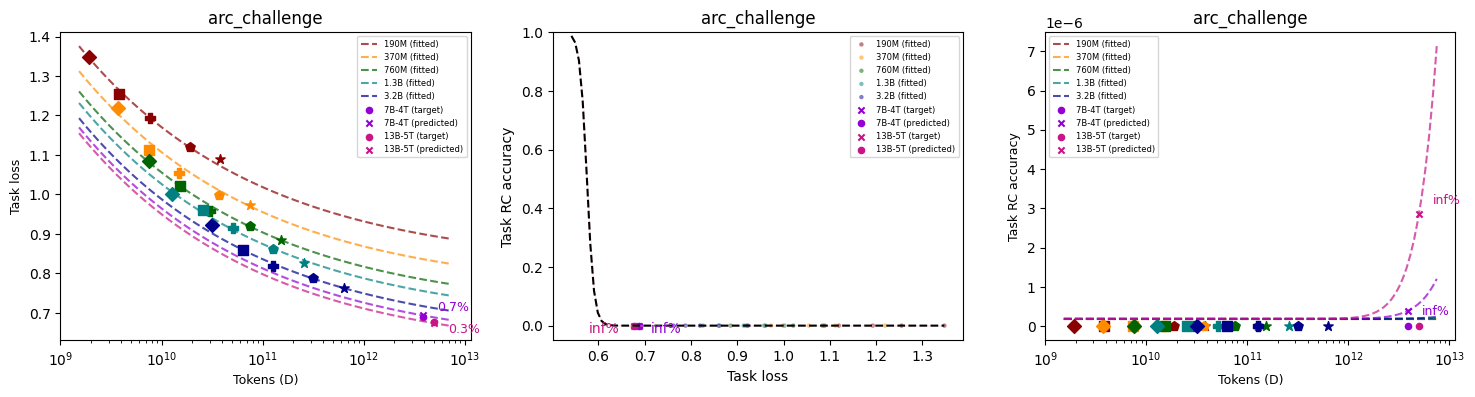

In [9]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=all_ladder_models,
    eval_models=["peteish7", "peteish13-highlr"],
    config_path=ladder_config_path,
    axes=axes[0],
)